In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path(
    "/Users/nzs33/Desktop/newcastle/pro-kalman-filter"
).resolve()

REBAYES_SRC = PROJECT_ROOT / "src"

assert (REBAYES_SRC / "rebayes_mini" / "__init__.py").exists(), (
    f"rebayes_mini source not found at {REBAYES_SRC}"
)

src_string = str(REBAYES_SRC)

if src_string not in sys.path:
    sys.path.insert(0, src_string)

import rebayes_mini

print("Python:", sys.executable)
print("rebayes_mini:", rebayes_mini.__file__)

Python: /Users/nzs33/Desktop/newcastle/pro-kalman-filter/.venv/bin/python
rebayes_mini: /Users/nzs33/Desktop/newcastle/pro-kalman-filter/src/rebayes_mini/__init__.py


In [2]:
import jax
import chex
import numpy as np
import pandas as pd
import seaborn as sns
import jax.numpy as jnp
import matplotlib.pyplot as plt
from functools import partial
from rebayes_mini import callbacks

cmap = {
    "EKF-IW": "crimson",
    "EKF": "lightseagreen",
    "WoLF-IMQ": "dodgerblue",
    "WoLF-MD": "gold",
    "EKF-B": "darkorange",
    "EKF-PrO": "mediumorchid",
}

def euler_step(y, i, dt, f):
    h = dt
    t = dt * i
    k1 = h * f(y, t, i)
    return y + k1

def rk4_step(y, i, dt, f):
    h = dt
    t = dt * i
    k1 = h * f(y, t, i)
    k2 = h * f(y + k1 / 2, dt * i + h / 2, i)
    k3 = h * f(y + k2 / 2, t + h / 2, i)
    k4 = h * f(y + k3, t + h, i)

    y_next = y + 1 / 6 * (k1 + 2 * k2 + 2 * k3 + k4)
    return y_next

@partial(jax.jit, static_argnames=("f",))
def solve(ys, dt, N, f):
    @jax.jit
    def step(i, ys):
        ysi = euler_step(ys[i - 1], i, dt, f)
        return ys.at[i].set(ysi)
    return jax.lax.fori_loop(1, N, step, ys)

In [3]:
errs = {}

In [4]:
D = 60
N = 10000
dt = 0.002
sigma = 1.0
F = 8.0
n_hidden = 2

@partial(jax.vmap, in_axes=(None, 0, None))
def fcoord(x, k, D):
    xdot = (x[(k + 1) % D] - x[k - 2]) * x[k - 1] - x[k] + F
    return xdot

key = jax.random.PRNGKey(315)
key_init, key_sim, key_eval = jax.random.split(key, 3)
key_state, key_measurement = jax.random.split(key_sim)

transition_prob = 0.995
key_hidden, key_state = jax.random.split(key_state)
transition_state = jnp.ones((n_hidden, n_hidden)) * 1/(n_hidden-1) * (1-transition_prob)
transition_state = transition_state.at[jnp.diag_indices_from(transition_state)].set(transition_prob)

key_hidden, key_state = jax.random.split(key_state)
phi_hidden = jax.random.normal(key_hidden, (D, n_hidden-1)) * sigma
phi_hidden = jnp.concatenate([jnp.zeros((D, 1)), phi_hidden], -1)
observation_covariance = 5.0

@jax.jit
def f(x, t, i, regime):
    keyt = jax.random.fold_in(key_state, i)
    key_regime, keyt = jax.random.split(keyt)
    probabilities = transition_state[regime, :]
    logits = jnp.log(probabilities)
    regime_next = jax.random.categorical(key_regime, logits)

    ixs = jnp.arange(D)
    xdot = fcoord(x, ixs, D) + phi_hidden[:, regime_next]
    return xdot, regime_next

x0 = jax.random.normal(key_init, (D,))
x_init = jnp.copy(x0)
xs = jnp.zeros((N,) + x0.shape)
xs = xs.at[0].set(x0)
fpart = partial(f, D=D)
regime = int(0)
regs = [0]
for i in range(1, N):
    xdot, regime = f(x0, i * dt, i, regime)
    x0 = x0 + dt * xdot
    regs.append(regime)
    xs = xs.at[i].set(x0)


ys = xs + jnp.sqrt(observation_covariance) * jax.random.normal(key_measurement, xs.shape)
range_time = np.arange(N) * dt

def latent_fn(x):
    """
    State function
    """
    @jax.jit
    def f(x, t, _):
        ixs = jnp.arange(D)
        return fcoord(x, ixs, D)
    
    return euler_step(x, 0, dt, f)


def obs_fn(x, _):#, key, i):
    """
    Measurement function
    """
    #err = jax.random.normal(key, (D,))
    return x

In [5]:
#from rebayes_mini.methods import robust_filter as rkf
from profilter import ExtendedKalmanFilter
method = "EKF"

nsteps = xs.shape[0]
agent_imq = ExtendedKalmanFilter(
        latent_fn, obs_fn,
        dynamics_covariance=jnp.eye(D) * jnp.square(sigma * dt),
        observation_covariance=observation_covariance * jnp.eye(D),
    )

init_bel = agent_imq.init_bel(x_init, cov=1.0)
filterfn = partial(agent_imq.scan, callback_fn=callbacks.get_updated_mean)
_, hist = filterfn(init_bel, ys, jnp.ones(nsteps))
err = jnp.sqrt(jnp.sum(jnp.square(hist - xs), -1))
errs[method] = err
jnp.mean(jnp.square(hist-xs))

Array(0.7963798, dtype=float32)

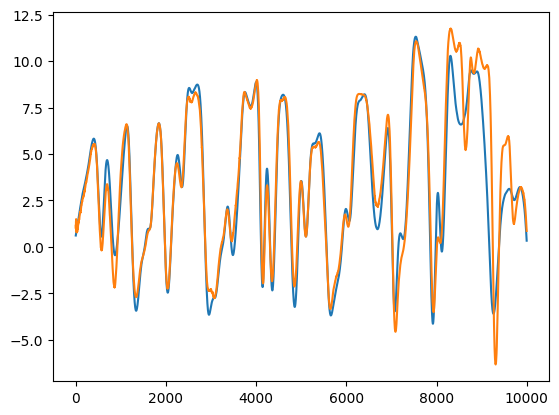

In [6]:
plt.plot(xs[:, 12])
plt.plot(hist[:, 12])

In [8]:
from profilter_rebuttal import PrOFilter
method = "EKF-PrO"

nsteps = xs.shape[0]
agent_imq = PrOFilter(
        latent_fn, obs_fn,
        dynamics_covariance=jnp.eye(D) * jnp.square(sigma * dt),
        observation_covariance=observation_covariance * jnp.eye(D),
        #soft_threshold=1e8,
        #n_inner=100,
        n_inner=3,
        n_outer=10,
    )

init_bel = agent_imq.init_bel(x_init, cov=1.0)
filterfn = partial(agent_imq.scan, callback_fn=callbacks.get_updated_mean)
_, hist1 = filterfn(init_bel, ys, jnp.ones(nsteps))

err = jnp.sqrt(jnp.sum(jnp.square(hist1 - xs), -1))
errs[method] = err
jnp.mean(jnp.square(hist1-xs))

Array(0.13968594, dtype=float32)

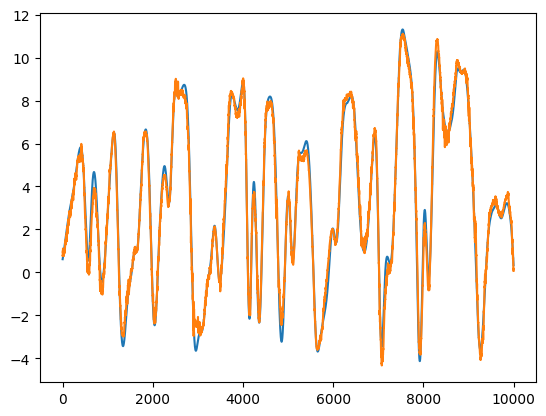

In [9]:
plt.plot(xs[:, 12])
plt.plot(hist1[:, 12])

In [11]:
@jax.jit
def filter_kfb(alpha, beta, n_inner, measurements, state):
    """
    Outlier ekf
    """
    n_inner = n_inner.astype(int)
    agent = rkf.ExtendedKalmanFilterBernoulli(
        latent_fn, obs_fn,
        dynamics_covariance=jnp.eye(D) * jnp.square(sigma * dt),
        observation_covariance=observation_covariance * jnp.eye(D),
        alpha=alpha,
        beta=beta,
        tol_inlier=1e-7,
        n_inner=n_inner,
    )

    init_bel = agent.init_bel(x_init, cov=1.0)
    
    _, hist = agent.scan(
        init_bel, measurements, jnp.ones(N), callback_fn=callbacks.get_updated_mean
    )

    err = jnp.sqrt(jnp.power(hist - state, 2).sum(axis=0))
    return err, hist


@jax.jit
def bo_filter_kfb(alpha, beta, n_inner):
    err, _ = filter_kfb(alpha, beta, n_inner, ys, xs)
    err = -err.max()
    err = jax.lax.cond(jnp.isnan(err), lambda: -1e6, lambda: err)
    return err

In [12]:
from bayes_opt import BayesianOptimization
from rebayes_mini import callbacks
from bayes_opt import BayesianOptimization
from rebayes_mini.methods import student_t_filter as stf
from rebayes_mini.methods import gauss_filter as kf
from rebayes_mini.methods import robust_filter as rkf

bo = BayesianOptimization(
    bo_filter_kfb,
    pbounds={
        "alpha": (0.0, 5.0),
        "beta": (0.0, 5.0),
        "n_inner": (1, 10),
    },
    random_state=314,
    verbose=1
)
bo.maximize(init_points=20, n_iter=30)

|   iter    |  target   |   alpha   |   beta    |  n_inner  |
-------------------------------------------------------------


In [13]:
method = "EKF-B"
alpha = bo.max["params"]["alpha"]
beta = bo.max["params"]["beta"]
n_inner = bo.max["params"]["n_inner"]

err, hist = filter_kfb(alpha, beta, n_inner, ys, xs)
err = jnp.sqrt(jnp.sum(jnp.square(hist - xs), -1))
errs[method] = err
jnp.mean(jnp.square(hist-xs))

Array(nan, dtype=float32)

In [15]:
@jax.jit
def filter_wlfmd(threshold, measurements, state):
    agent = rkf.ExtendedKalmanFilterMD(
        latent_fn, obs_fn,
        dynamics_covariance=jnp.eye(D) * jnp.square(sigma * dt),
        observation_covariance=observation_covariance * jnp.eye(D),
        threshold=threshold
    )
    
    init_bel = agent.init_bel(x_init, cov=1.0)
    
    _, hist = agent.scan(
        init_bel, measurements, jnp.ones(N), callback_fn=callbacks.get_updated_mean
    )

    err = jnp.sqrt(jnp.power(hist - state, 2).sum(axis=0))
    return err, hist


@jax.jit
def bo_filter_wlfmd(threshold):
    err, _ = filter_wlfmd(threshold, ys, xs)
    err = -err.max()
    err = jax.lax.cond(jnp.isnan(err), lambda: -1e6, lambda: err)
    return -err.max()

In [16]:
bo = BayesianOptimization(
    bo_filter_wlfmd,
    pbounds={
        "threshold": (1e-6, 20)
    },
    random_state=314,
    verbose=1
)
bo.maximize(init_points=20, n_iter=30)

|   iter    |  target   | threshold |
-------------------------------------


In [17]:
method = "WoLF-MD"

threshold = bo.max["params"]["threshold"]
err, hist = filter_wlfmd(1.0, ys, xs)
err = jnp.sqrt(jnp.sum(jnp.square(hist - xs), -1))
errs[method] = err
jnp.mean(jnp.square(hist-xs))

Array(22.49473, dtype=float32)

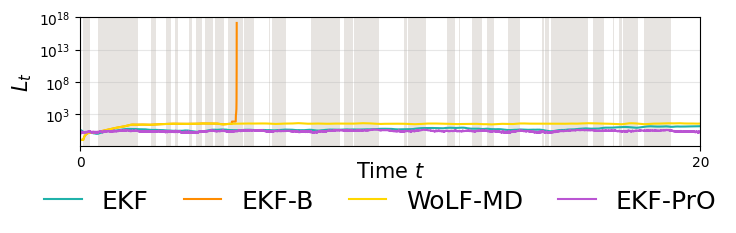

In [18]:
delta = dt
n_steps = err.shape[0]
ts = jnp.arange(n_steps) * delta
colors = {
    0: "white",
    1: "#D8D3CD",
}
label = np.array(regs)

import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 2.8))

for i, value in enumerate(np.array(label)):
    ax.axvspan(
        i * delta,
        (i + 1) * delta,
        color=colors[value],
        alpha=0.6,
        linewidth=0,
    )

for m in ["EKF", "EKF-B", "WoLF-MD", "EKF-PrO"]:
    ax.plot(ts, errs[m], label=m, c=cmap[m])

ax.set_xlim(0, len(label) * delta)
ax.set_ylabel(r"$L_t$", fontsize=15)
ax.set_yscale("log")
ax.grid(alpha=0.3)
ax.set_xticks([0, 20])

# Put xlabel close to the axis, but not in the legend area
ax.set_xlabel(r"Time $t$", fontsize=15)
ax.xaxis.set_label_coords(0.5, -0.12)

# Reserve enough bottom margin for both xlabel and legend
fig.subplots_adjust(bottom=0.42)

handles, legend_labels = ax.get_legend_handles_labels()

fig.legend(
    handles,
    legend_labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.10),
    ncol=len(legend_labels),
    fontsize=18,
    frameon=False,
    handlelength=1.5,
    columnspacing=1.4,
)

fig.savefig("error_lorenz.pdf", bbox_inches="tight")

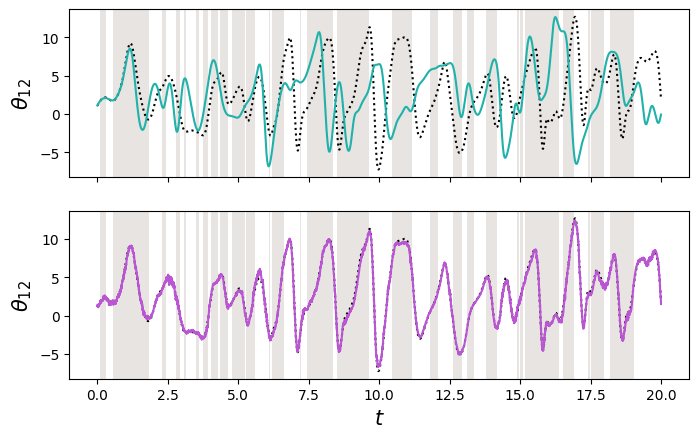

In [19]:
delta = dt
n_steps = err.shape[0]
ts = jnp.arange(n_steps) * delta
colors = {
    0: "white",
    1: "#D8D3CD",
}
label = np.array(regs)

import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4.8), nrows=2, ncols=1, sharex=True)

for i, value in enumerate(np.array(label)):
    for a in ax:
        a.axvspan(
        i * delta,
        (i + 1) * delta,
        color=colors[value],
        alpha=0.6,
        linewidth=0,
        )

idx = jnp.argmax(jnp.mean(jnp.square(hist-xs), 0))


for a in ax:
    a.plot(ts, xs[:, idx], c='k', linestyle='dotted')

ax[0].plot(ts, hist[:, idx], c=cmap['EKF'])
ax[1].plot(ts, hist1[:, idx], c=cmap['EKF-PrO'])

for a in ax:
    a.set_ylabel(r'$\theta_{12}$', fontsize=15)

ax[1].set_xlabel(r'$t$', fontsize=15)
fig.savefig("lorenz_trace.pdf", bbox_inches="tight")